<a href="https://colab.research.google.com/github/Bryan-ing/Master-s-Degree-in-AI/blob/main/Estadistica_Bayesiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase 5: Estadística Bayesiana
## Notebook de Demostración - Maestría en Inteligencia Artificial

En esta clase aprenderemos:
- Probabilidad condicional
- Teorema de Bayes
- Prior, Likelihood y Posterior
- Actualización Bayesiana
- Aplicaciones prácticas

---
## 1. Configuración e Importación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install empiricaldist
from empiricaldist import Pmf

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Librerías importadas correctamente")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.9.0-py3-none-any.whl size=14297 sha256=d6a76f45d2dd0b86748142525cc2938a194a1d1c4649cd2140e484a5071a977c
  Stored in directory: /root/.cache/pip/wheels/26/56/da/ea90b6b66dc5e72379a64e2819815066873f00c1350126e876
Successfully built empiricaldist
Librerías importadas correctamente


---
## 2. Probabilidad Condicional

La **probabilidad condicional** es la probabilidad de un evento dado que otro evento ha ocurrido.

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

**Ejemplo:** ¿Cuál es la probabilidad de que una persona sea banquera dado que es feminista?

In [3]:
# Cargar datos GSS
import os
from urllib.request import urlretrieve

url = "https://github.com/AllenDowney/ThinkBayes2/raw/master/data/gss_bayes.csv"
filename = "gss_bayes.csv"

if not os.path.exists(filename):
    urlretrieve(url, filename)

gss = pd.read_csv(filename)

print("═" * 60)
print("ANÁLISIS: El Problema de Linda la Banquera")
print("═" * 60)

# Definir variables
# Código 6870 = Banking and related activities
banker = (gss['indus10'] == 6870)

# Feminista: asumimos que las mujeres que votaron por derechos de la mujer
# Para este ejemplo, usamos una simplificación basada en sexo y política
feminist = (gss['sex'] == 2) & (gss['polviews'] <= 4)  # Mujeres liberales

# Probabilidades básicas
p_banker = banker.mean()
p_feminist = feminist.mean()
p_banker_and_feminist = (banker & feminist).mean()

print(f"\n Probabilidades calculadas del GSS:")
print(f"  P(Banquera)              = {p_banker:.4f} ({p_banker*100:.2f}%)")
print(f"  P(Feminista)             = {p_feminist:.4f} ({p_feminist*100:.2f}%)")
print(f"  P(Banquera ∩ Feminista)  = {p_banker_and_feminist:.4f} ({p_banker_and_feminist*100:.2f}%)")

# Probabilidad condicional
p_banker_given_feminist = p_banker_and_feminist / p_feminist

print(f"\n Probabilidad Condicional:")
print(f"  P(Banquera | Feminista)  = {p_banker_given_feminist:.4f} ({p_banker_given_feminist*100:.2f}%)")

print(f"\n Conclusión del problema de Linda:")
print(f"   P(Banquera) = {p_banker*100:.2f}% > P(Banquera | Feminista) = {p_banker_given_feminist*100:.2f}%")
print(f"   ¡La conjunción NO puede ser más probable que cada evento por separado!")

════════════════════════════════════════════════════════════
ANÁLISIS: El Problema de Linda la Banquera
════════════════════════════════════════════════════════════

 Probabilidades calculadas del GSS:
  P(Banquera)              = 0.0148 (1.48%)
  P(Feminista)             = 0.3673 (36.73%)
  P(Banquera ∩ Feminista)  = 0.0074 (0.74%)

 Probabilidad Condicional:
  P(Banquera | Feminista)  = 0.0203 (2.03%)

 Conclusión del problema de Linda:
   P(Banquera) = 1.48% > P(Banquera | Feminista) = 2.03%
   ¡La conjunción NO puede ser más probable que cada evento por separado!


---
## 3. Teorema de Bayes

El **Teorema de Bayes** nos permite actualizar nuestras creencias dada nueva evidencia:

$$P(H|E) = \frac{P(H) \cdot P(E|H)}{P(E)}$$

Donde:
- $P(H)$ = **Prior**: Probabilidad inicial de la hipótesis
- $P(E|H)$ = **Likelihood**: Probabilidad de la evidencia dada la hipótesis
- $P(E)$ = **Evidence**: Probabilidad total de la evidencia
- $P(H|E)$ = **Posterior**: Probabilidad actualizada de la hipótesis

### 3.1 El Problema de las Galletas (Cookie Problem)

> Tenemos dos bowls:
> - Bowl 1: 30 vainilla, 10 chocolate
> - Bowl 2: 20 vainilla, 20 chocolate
>
> Elegimos un bowl al azar y sacamos una galleta vainilla. ¿De qué bowl viene?

In [5]:
print("═" * 60)
print("PROBLEMA DE LAS GALLETAS")
print("═" * 60)

# Priors: probabilidad de elegir cada bowl
p_bowl1 = 0.5
p_bowl2 = 0.5

print(f"\n Priors (antes de ver la galleta):")
print(f"  P(Bowl 1) = {p_bowl1}")
print(f"  P(Bowl 2) = {p_bowl2}")

# Likelihoods: probabilidad de sacar vainilla de cada bowl
p_vanilla_given_bowl1 = 30 / 40  # 30 vainilla de 40 total - probabilidad de sacar una de vainilla es de 0.75
p_vanilla_given_bowl2 = 20 / 40  # 20 vainilla de 40 total - probabilidad de sacar una de vainilla es de 0.50

print(f"\n Likelihoods:")
print(f"  P(Vainilla | Bowl 1) = {p_vanilla_given_bowl1}") #probabilidad de sacar una de vainilla es de 0.75
print(f"  P(Vainilla | Bowl 2) = {p_vanilla_given_bowl2}") #probabilidad de sacar una de vainilla es de 0.50


# Total probability of evidence
p_vanilla = (p_bowl1 * p_vanilla_given_bowl1 +
             p_bowl2 * p_vanilla_given_bowl2)

print(f"\n Evidence:")
print(f"  P(Vainilla) = {p_vanilla:.4f}")

# Apply Bayes' Theorem
p_bowl1_given_vanilla = (p_bowl1 * p_vanilla_given_bowl1) / p_vanilla
p_bowl2_given_vanilla = (p_bowl2 * p_vanilla_given_bowl2) / p_vanilla

print(f"\n Posteriors (después de ver vainilla):")
print(f"  P(Bowl 1 | Vainilla) = {p_bowl1_given_vanilla:.4f} ({p_bowl1_given_vanilla*100:.1f}%)")
print(f"  P(Bowl 2 | Vainilla) = {p_bowl2_given_vanilla:.4f} ({p_bowl2_given_vanilla*100:.1f}%)")

print(f"\n Conclusión: La galleta vainilla es más probable que venga del Bowl 1")
print(f"   porque tiene mayor proporción de galletas vainilla.")

════════════════════════════════════════════════════════════
PROBLEMA DE LAS GALLETAS
════════════════════════════════════════════════════════════

 Priors (antes de ver la galleta):
  P(Bowl 1) = 0.5
  P(Bowl 2) = 0.5

 Likelihoods:
  P(Vainilla | Bowl 1) = 0.75
  P(Vainilla | Bowl 2) = 0.5

 Evidence:
  P(Vainilla) = 0.6250

 Posteriors (después de ver vainilla):
  P(Bowl 1 | Vainilla) = 0.6000 (60.0%)
  P(Bowl 2 | Vainilla) = 0.4000 (40.0%)

 Conclusión: La galleta vainilla es más probable que venga del Bowl 1
   porque tiene mayor proporción de galletas vainilla.


### 3.2 Tabla de Bayes

Una forma conveniente de organizar el cálculo de Bayes.

In [6]:
# Crear tabla de Bayes con pandas
table = pd.DataFrame(index=['Bowl 1', 'Bowl 2'])

# Priors
table['Prior'] = [0.5, 0.5]

# Likelihoods (probabilidad de vainilla)
table['Likelihood'] = [30/40, 20/40]

# Unnormalized posterior (Prior * Likelihood)
table['Unnorm'] = table['Prior'] * table['Likelihood']

# Normalizar (dividir por la suma)
prob_total = table['Unnorm'].sum()
table['Posterior'] = table['Unnorm'] / prob_total # el posterior nunca será mayor a 1. Esto se debe a que la probabilidad, por definición,
#siempre se encuentra en el rango de 0 a 1 (inclusive)

print("TABLA DE BAYES:")
print("=" * 60)
print(table.round(4))

print(f"\n Suma de posteriors: {table['Posterior'].sum():.4f} (debe ser 1.0)")

TABLA DE BAYES:
        Prior  Likelihood  Unnorm  Posterior
Bowl 1    0.5        0.75   0.375        0.6
Bowl 2    0.5        0.50   0.250        0.4

 Suma de posteriors: 1.0000 (debe ser 1.0)


---
## 4. Actualización Bayesiana con Múltiples Datos

La verdadera potencia del enfoque bayesiano: ¡podemos actualizar nuestras creencias iterativamente!

In [7]:
print("═" * 60)
print("ACTUALIZACIÓN BAYESIANA ITERATIVA")
print("═" * 60)

# Escenario: Sacamos 3 galletas: vainilla, vainilla, chocolate
galletas = ['vainilla', 'vainilla', 'chocolate']

# Inicializar priors
prior_bowl1 = 0.5
prior_bowl2 = 0.5

print(f"\n Secuencia de galletas: {galletas}")
print("\n" + "-" * 60) #separador de 60 guiones

# Probabilidades de cada tipo de galleta por bowl
likelihoods = {
    'Bowl 1': {'vainilla': 30/40, 'chocolate': 10/40},
    'Bowl 2': {'vainilla': 20/40, 'chocolate': 20/40}
}

# Historial para visualización
history = [(prior_bowl1, prior_bowl2)]

for i, galleta in enumerate(galletas, 1):
    print(f"\n Paso {i}: Sacamos {galleta.upper()}")
    print(f"   Antes: P(Bowl 1) = {prior_bowl1:.4f}, P(Bowl 2) = {prior_bowl2:.4f}")

    # Likelihoods
    like1 = likelihoods['Bowl 1'][galleta]
    like2 = likelihoods['Bowl 2'][galleta]

    # Unnormalized posteriors
    unnorm1 = prior_bowl1 * like1
    unnorm2 = prior_bowl2 * like2
    total = unnorm1 + unnorm2

    # Normalizar
    prior_bowl1 = unnorm1 / total
    prior_bowl2 = unnorm2 / total

    print(f"   Después: P(Bowl 1) = {prior_bowl1:.4f}, P(Bowl 2) = {prior_bowl2:.4f}")

    history.append((prior_bowl1, prior_bowl2))

print("\n" + "=" * 60)
print(f"\n RESULTADO FINAL:")
print(f"  P(Bowl 1 | datos) = {prior_bowl1:.4f} ({prior_bowl1*100:.1f}%)")
print(f"  P(Bowl 2 | datos) = {prior_bowl2:.4f} ({prior_bowl2*100:.1f}%)")

════════════════════════════════════════════════════════════
ACTUALIZACIÓN BAYESIANA ITERATIVA
════════════════════════════════════════════════════════════

 Secuencia de galletas: ['vainilla', 'vainilla', 'chocolate']

------------------------------------------------------------

 Paso 1: Sacamos VAINILLA
   Antes: P(Bowl 1) = 0.5000, P(Bowl 2) = 0.5000
   Después: P(Bowl 1) = 0.6000, P(Bowl 2) = 0.4000

 Paso 2: Sacamos VAINILLA
   Antes: P(Bowl 1) = 0.6000, P(Bowl 2) = 0.4000
   Después: P(Bowl 1) = 0.6923, P(Bowl 2) = 0.3077

 Paso 3: Sacamos CHOCOLATE
   Antes: P(Bowl 1) = 0.6923, P(Bowl 2) = 0.3077
   Después: P(Bowl 1) = 0.5294, P(Bowl 2) = 0.4706


 RESULTADO FINAL:
  P(Bowl 1 | datos) = 0.5294 (52.9%)
  P(Bowl 2 | datos) = 0.4706 (47.1%)


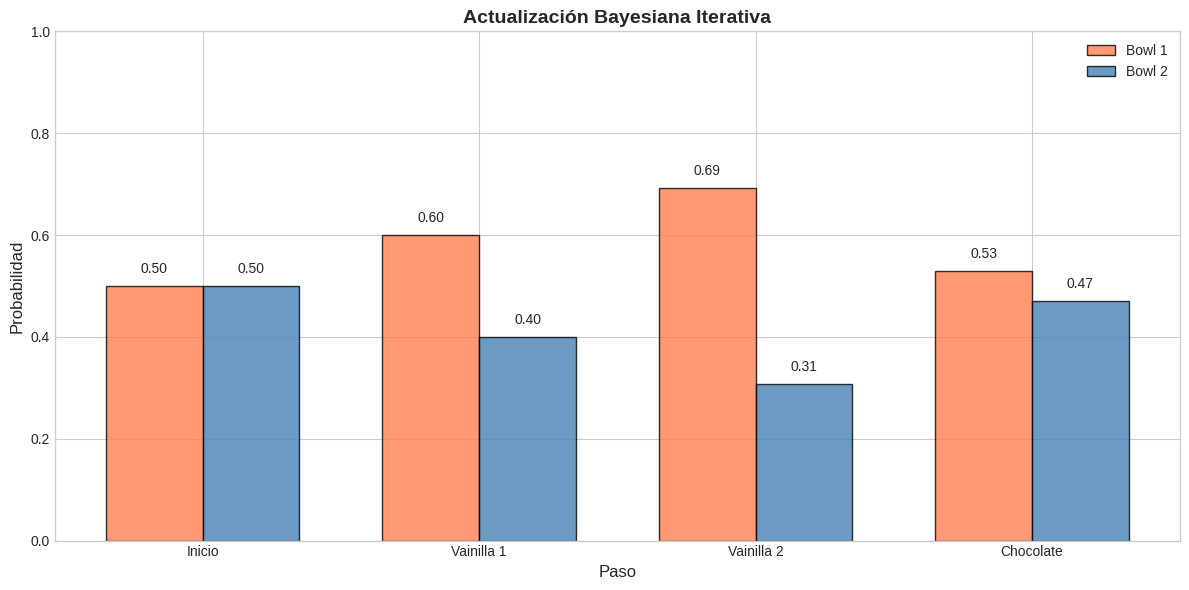


 Observación: Cada nueva evidencia actualiza nuestras creencias
   Las dos vainillas favorecieron al Bowl 1
   El chocolate lo favoreció menos (pero sigue siendo más probable Bowl 1)


In [8]:
# Visualizar la actualización
fig, ax = plt.subplots(figsize=(12, 6))

steps = ['Inicio', 'Vainilla 1', 'Vainilla 2', 'Chocolate']
bowl1_probs = [h[0] for h in history]
bowl2_probs = [h[1] for h in history]

x = np.arange(len(steps))
width = 0.35

bars1 = ax.bar(x - width/2, bowl1_probs, width, label='Bowl 1', color='coral', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, bowl2_probs, width, label='Bowl 2', color='steelblue', alpha=0.8, edgecolor='black')

ax.set_xlabel('Paso', fontsize=12)
ax.set_ylabel('Probabilidad', fontsize=12)
ax.set_title('Actualización Bayesiana Iterativa', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(steps)
ax.legend()
ax.set_ylim(0, 1)

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n Observación: Cada nueva evidencia actualiza nuestras creencias")
print("   Las dos vainillas favorecieron al Bowl 1")
print("   El chocolate lo favoreció menos (pero sigue siendo más probable Bowl 1)")

---
## 5. El Problema de Monty Hall

Un clásico de probabilidad que confunde a muchas personas:

> Hay 3 puertas. Detrás de una hay un auto, detrás de las otras dos hay cabras.
> Tú eliges una puerta (digamos la 1).
> El presentador (que sabe dónde está el auto) abre otra puerta mostrando una cabra.
> Te pregunta: ¿quieres cambiar de puerta?

**Pregunta:** ¿Es mejor cambiar o quedarse?

In [9]:
print("═" * 60)
print("PROBLEMA DE MONTY HALL")
print("═" * 60)

print(f"\n Análisis Bayesiano:")
print(f"  Tú eliges la Puerta 1")
print(f"  Monty abre la Puerta 3 mostrando una cabra")
print(f"  ¿Cambias a la Puerta 2?")

# Priors: el auto puede estar en cualquiera de las 3 puertas
priors = {'Puerta 1': 1/3, 'Puerta 2': 1/3, 'Puerta 3': 1/3}

print(f"\n Priors (antes de que Monty abra):")
for puerta, prob in priors.items():
    print(f"  P({puerta}) = {prob:.4f}")

# Likelihoods: probabilidad de que Monty abra la Puerta 3
# Si el auto está en 1: Monty puede abrir 2 o 3 (elige al azar)
# Si el auto está en 2: Monty DEBE abrir 3
# Si el auto está en 3: Monty NO puede abrir 3
likelihoods = {
    'Puerta 1': 0.5,  # Monty elige entre 2 y 3
    'Puerta 2': 1.0,  # Monty debe abrir 3
    'Puerta 3': 0.0   # Monty no abriría 3 si el auto está ahí
}

print(f"\n Likelihoods (P(Monty abre 3 | auto en X)):")
for puerta, like in likelihoods.items():
    print(f"  P(Abre 3 | {puerta}) = {like}")

# Calcular posteriors
unnorm = {p: priors[p] * likelihoods[p] for p in priors}
total = sum(unnorm.values())
posteriors = {p: unnorm[p] / total for p in unnorm}

print(f"\n Posteriors (dado que Monty abrió 3):")
for puerta, prob in posteriors.items():
    print(f"  P({puerta} | Abre 3) = {prob:.4f} ({prob*100:.1f}%)")

print(f"\n CONCLUSIÓN:")
print(f"  Si te quedas con Puerta 1: {posteriors['Puerta 1']*100:.1f}% de ganar")
print(f"  Si cambias a Puerta 2: {posteriors['Puerta 2']*100:.1f}% de ganar")
print(f"\n  ¡SIEMPRE ES MEJOR CAMBIAR! Duplicas tus probabilidades.")

════════════════════════════════════════════════════════════
PROBLEMA DE MONTY HALL
════════════════════════════════════════════════════════════

 Análisis Bayesiano:
  Tú eliges la Puerta 1
  Monty abre la Puerta 3 mostrando una cabra
  ¿Cambias a la Puerta 2?

 Priors (antes de que Monty abra):
  P(Puerta 1) = 0.3333
  P(Puerta 2) = 0.3333
  P(Puerta 3) = 0.3333

 Likelihoods (P(Monty abre 3 | auto en X)):
  P(Abre 3 | Puerta 1) = 0.5
  P(Abre 3 | Puerta 2) = 1.0
  P(Abre 3 | Puerta 3) = 0.0

 Posteriors (dado que Monty abrió 3):
  P(Puerta 1 | Abre 3) = 0.3333 (33.3%)
  P(Puerta 2 | Abre 3) = 0.6667 (66.7%)
  P(Puerta 3 | Abre 3) = 0.0000 (0.0%)

 CONCLUSIÓN:
  Si te quedas con Puerta 1: 33.3% de ganar
  Si cambias a Puerta 2: 66.7% de ganar

  ¡SIEMPRE ES MEJOR CAMBIAR! Duplicas tus probabilidades.


In [10]:
# Simulación para verificar
np.random.seed(42)
n_simulations = 100000

wins_stay = 0
wins_switch = 0

for _ in range(n_simulations):
    # Colocar auto aleatoriamente
    auto_door = np.random.randint(0, 3)

    # Jugador elige puerta 0
    player_choice = 0

    # Monty abre una puerta con cabra
    available_doors = [d for d in range(3) if d != player_choice and d != auto_door]
    monty_opens = np.random.choice(available_doors) if len(available_doors) > 1 else available_doors[0]

    # Puerta para cambiar
    switch_door = [d for d in range(3) if d != player_choice and d != monty_opens][0]

    # Estrategia: quedarse
    if player_choice == auto_door:
        wins_stay += 1

    # Estrategia: cambiar
    if switch_door == auto_door:
        wins_switch += 1

print(f"\n SIMULACIÓN ({n_simulations:,} juegos):")
print(f"  Ganar quedándose: {wins_stay/n_simulations*100:.2f}%")
print(f"  Ganar cambiando: {wins_switch/n_simulations*100:.2f}%")
print(f"\n  La simulación confirma el análisis bayesiano!")


 SIMULACIÓN (100,000 juegos):
  Ganar quedándose: 33.36%
  Ganar cambiando: 66.64%

  La simulación confirma el análisis bayesiano!


---
## 6. Estimación Bayesiana de Proporciones

Usemos un ejemplo del GSS: ¿Qué proporción de la población es feminista?

In [11]:
print("═" * 60)
print("ESTIMACIÓN BAYESIANA: Proporción de Feministas")
print("═" * 60)

# Datos observados
n_feminist = feminist.sum()
n_total = len(gss)

print(f"\n Datos observados (GSS):")
print(f"  Feministas: {n_feminist:,}")
print(f"  Total: {n_total:,}")
print(f"  Proporción muestral: {n_feminist/n_total:.4f} ({n_feminist/n_total*100:.2f}%)")

# Enfoque frecuentista: intervalo de confianza
p_mle = n_feminist / n_total
se = np.sqrt(p_mle * (1 - p_mle) / n_total)
ci_lower = p_mle - 1.96 * se
ci_upper = p_mle + 1.96 * se

print(f"\n Enfoque Frecuentista (MLE):")
print(f"  Estimación puntual: {p_mle:.4f}")
print(f"  IC 95%: [{ci_lower:.4f}, {ci_upper:.4f}]")

# Enfoque Bayesiano: usar prior uniforme (Beta(1,1))
# Posterior = Beta(α + éxitos, β + fracasos)
alpha_prior = 1
beta_prior = 1

alpha_post = alpha_prior + n_feminist
beta_post = beta_prior + (n_total - n_feminist)

# Media posterior
mean_post = alpha_post / (alpha_post + beta_post)

# Intervalo de credibilidad 95% (usando percentiles de Beta)
from scipy.stats import beta
cred_lower = beta.ppf(0.025, alpha_post, beta_post)
cred_upper = beta.ppf(0.975, alpha_post, beta_post)

print(f"\n Enfoque Bayesiano (Prior Uniforme):")
print(f"  Posterior: Beta({alpha_post}, {beta_post})")
print(f"  Media posterior: {mean_post:.4f}")
print(f"  IC 95% (Credibilidad): [{cred_lower:.4f}, {cred_upper:.4f}]")

print(f"\n Interpretación Bayesiana:")
print(f"   'Hay un 95% de probabilidad de que la proporción real esté")
print(f"    entre {cred_lower:.4f} y {cred_upper:.4f}'")
print(f"\n   (vs. frecuentista: 'El 95% de los intervalos contienen el parámetro')")

════════════════════════════════════════════════════════════
ESTIMACIÓN BAYESIANA: Proporción de Feministas
════════════════════════════════════════════════════════════

 Datos observados (GSS):
  Feministas: 18,102
  Total: 49,290
  Proporción muestral: 0.3673 (36.73%)

 Enfoque Frecuentista (MLE):
  Estimación puntual: 0.3673
  IC 95%: [0.3630, 0.3715]

 Enfoque Bayesiano (Prior Uniforme):
  Posterior: Beta(18103, 31189)
  Media posterior: 0.3673
  IC 95% (Credibilidad): [0.3630, 0.3715]

 Interpretación Bayesiana:
   'Hay un 95% de probabilidad de que la proporción real esté
    entre 0.3630 y 0.3715'

   (vs. frecuentista: 'El 95% de los intervalos contienen el parámetro')


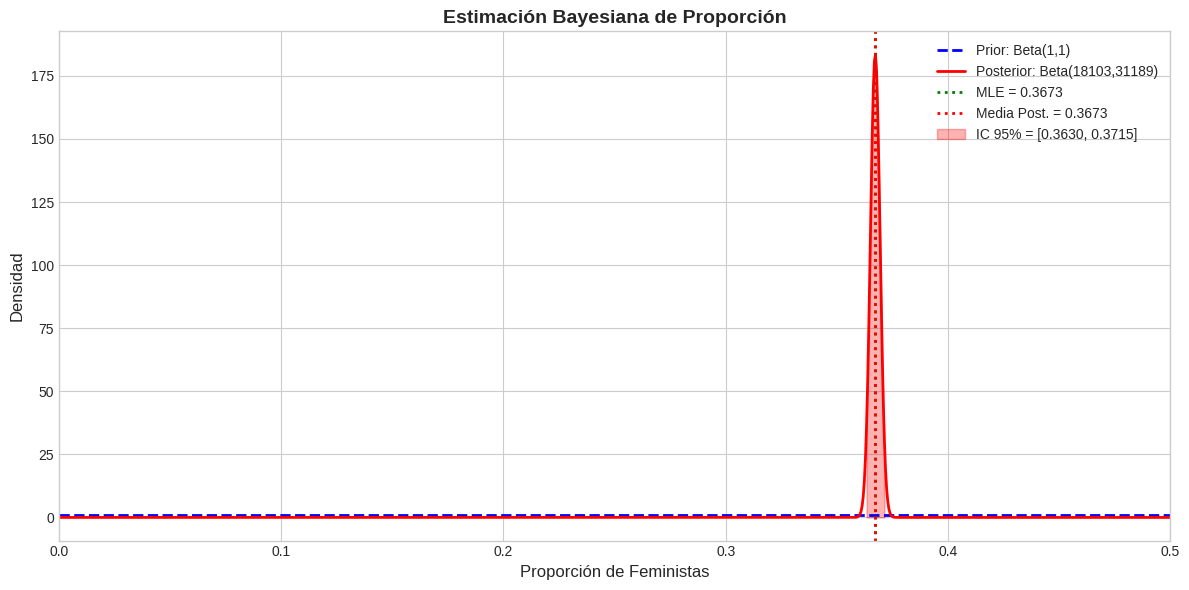


 Observación: Con muchos datos, el prior tiene poca influencia
   y la posterior se centra cerca del MLE (0.3673)


In [ ]:
# Visualizar prior, likelihood y posterior
from scipy.stats import beta

x = np.linspace(0, 0.5, 1000)

fig, ax = plt.subplots(figsize=(12, 6))

# Prior
prior = beta.pdf(x, alpha_prior, beta_prior)
ax.plot(x, prior, 'b--', linewidth=2, label=f'Prior: Beta({alpha_prior},{beta_prior})')

# Posterior
posterior = beta.pdf(x, alpha_post, beta_post)
ax.plot(x, posterior, 'r-', linewidth=2, label=f'Posterior: Beta({alpha_post},{beta_post:.0f})')

# Línea vertical para la estimación
ax.axvline(x=p_mle, color='green', linestyle=':', linewidth=2, label=f'MLE = {p_mle:.4f}')
ax.axvline(x=mean_post, color='red', linestyle=':', linewidth=2, label=f'Media Post. = {mean_post:.4f}')

# Sombrear intervalo de credibilidad
x_cred = x[(x >= cred_lower) & (x <= cred_upper)]
y_cred = beta.pdf(x_cred, alpha_post, beta_post)
ax.fill_between(x_cred, y_cred, alpha=0.3, color='red', label=f'IC 95% = [{cred_lower:.4f}, {cred_upper:.4f}]')

ax.set_xlabel('Proporción de Feministas', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Estimación Bayesiana de Proporción', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(0, 0.5)

plt.tight_layout()
plt.show()

print("\n Observación: Con muchos datos, el prior tiene poca influencia")
print(f"   y la posterior se centra cerca del MLE ({p_mle:.4f})")

---
## 7. Resumen: Frecuentista vs Bayesiano

In [ ]:
print("═" * 70)
print("COMPARACIÓN: ENFOQUE FRECUENTISTA VS BAYESIANO")
print("═" * 70)

comparison = pd.DataFrame({
    'Aspecto': [
        'Interpretación de probabilidad',
        'Parámetros',
        'Intervalo de confianza',
        'Usa información previa',
        'Resultado',
        'Computación'
    ],
    'Frecuentista': [
        'Frecuencia a largo plazo',
        'Fijos (desconocidos)',
        '95% de los intervalos contienen θ',
        'No',
        'Estimación puntual + IC',
        'Más simple'
    ],
    'Bayesiano': [
        'Grado de creencia',
        'Variables aleatorias',
        '95% de probabilidad de que θ esté en el intervalo',
        'Sí (prior)',
        'Distribución posterior completa',
        'Más complejo (MCMC, etc.)'
    ]
})

print("\n" + comparison.to_string(index=False))

print("\n\n ¿CUÁNDO USAR CADA ENFOQUE?")
print("\n Frecuentista:")
print("   • Muestras grandes")
print("   • Quieres simplicidad")
print("   • No tienes información previa confiable")
print("   • Resultados deben ser objetivos/reproducibles")

print("\n Bayesiano:")
print("   • Tienes información previa relevante")
print("   • Muestras pequeñas")
print("   • Necesitas una distribución completa del parámetro")
print("   • Actualización secuencial de creencias")
print("   • Modelos jerárquicos complejos")

══════════════════════════════════════════════════════════════════════
COMPARACIÓN: ENFOQUE FRECUENTISTA VS BAYESIANO
══════════════════════════════════════════════════════════════════════

                       Aspecto                      Frecuentista                                         Bayesiano
Interpretación de probabilidad          Frecuencia a largo plazo                                 Grado de creencia
                    Parámetros              Fijos (desconocidos)                              Variables aleatorias
        Intervalo de confianza 95% de los intervalos contienen θ 95% de probabilidad de que θ esté en el intervalo
        Usa información previa                                No                                        Sí (prior)
                     Resultado           Estimación puntual + IC                   Distribución posterior completa
                   Computación                        Más simple                         Más complejo (MCMC, etc.)


 ¿C

---
## 8. Resumen de la Clase

In [ ]:
print("═" * 70)
print("RESUMEN DE LA CLASE 5: Estadística Bayesiana")
print("═" * 70)

print("\n CONCEPTOS APRENDIDOS:")

print("\n1. PROBABILIDAD CONDICIONAL:")
print("   • P(A|B) = P(A ∩ B) / P(B)")

print("\n2. TEOREMA DE BAYES:")
print("   • P(H|E) = P(H) · P(E|H) / P(E)")

print("\n3. COMPONENTES:")
print("   • Prior P(H): Creencia inicial")
print("   • Likelihood P(E|H): Probabilidad de la evidencia")
print("   • Posterior P(H|E): Creencia actualizada")

print("\n4. ACTUALIZACIÓN BAYESIANA:")
print("   • Podemos actualizar iterativamente con nueva evidencia")
print("   • La posterior de hoy es el prior de mañana")

print("\n5. APLICACIONES:")
print("   • Problema de las galletas")
print("   • Problema de Monty Hall")
print("   • Estimación de proporciones")

print("\n EJEMPLOS ANALIZADOS:")
print(f"   • Cookie Problem: P(Bowl 1 | Vainilla) = {p_bowl1_given_vanilla:.2f}")
print(f"   • Monty Hall: P(Ganar | Cambiar) = {2/3:.2f}")
print(f"   • Feministas: Media posterior = {mean_post:.4f}")

print("\n PARA LA TAREA:")
print("   Practica aplicando el Teorema de Bayes a diferentes")
print("   escenarios y realiza actualizaciones bayesianas.")

print("\n" + "═" * 70)

══════════════════════════════════════════════════════════════════════
RESUMEN DE LA CLASE 5: Estadística Bayesiana
══════════════════════════════════════════════════════════════════════

 CONCEPTOS APRENDIDOS:

1. PROBABILIDAD CONDICIONAL:
   • P(A|B) = P(A ∩ B) / P(B)

2. TEOREMA DE BAYES:
   • P(H|E) = P(H) · P(E|H) / P(E)

3. COMPONENTES:
   • Prior P(H): Creencia inicial
   • Likelihood P(E|H): Probabilidad de la evidencia
   • Posterior P(H|E): Creencia actualizada

4. ACTUALIZACIÓN BAYESIANA:
   • Podemos actualizar iterativamente con nueva evidencia
   • La posterior de hoy es el prior de mañana

5. APLICACIONES:
   • Problema de las galletas
   • Problema de Monty Hall
   • Estimación de proporciones

 EJEMPLOS ANALIZADOS:
   • Cookie Problem: P(Bowl 1 | Vainilla) = 0.60
   • Monty Hall: P(Ganar | Cambiar) = 0.67
   • Feministas: Media posterior = 0.3673

 PARA LA TAREA:
   Practica aplicando el Teorema de Bayes a diferentes
   escenarios y realiza actualizaciones bayesianas.


---
## Referencias

- Downey, A. B. (2020). *Think Bayes: Bayesian Statistics in Python* (2nd ed.). O'Reilly Media.
- McElreath, R. (2020). *Statistical Rethinking: A Bayesian Course with Examples in R and Stan* (2nd ed.). CRC Press.
- Gelman, A., et al. (2013). *Bayesian Data Analysis* (3rd ed.). CRC Press.